# Tugas 3 — Agglomerative Hierarchical Clustering

**Mata Kuliah:** Data Mining

## Deskripsi
Algoritma **Agglomerative Clustering** termasuk *hierarchical clustering* dengan pendekatan **bottom-up**:

1. Setiap data dimulai sebagai klaster sendiri (jadi awalnya jumlah klaster = jumlah data).
2. Hitung jarak antar semua klaster (matriks jarak).
3. Gabungkan **dua klaster terdekat** menjadi satu.
4. Ulangi langkah 2 dan 3 sampai semua data tergabung dalam satu klaster.
5. Riwayat penggabungan divisualisasikan sebagai **dendrogram**.

Studi kasus: **6 mahasiswa** dengan atribut **Nilai Tugas** dan **Nilai Ujian**. Jumlah data sengaja dipilih kecil supaya seluruh langkah dapat di-*trace* manual.

Berbeda dari **K-Means** yang membutuhkan K di awal, agglomerative menghasilkan **hirarki klaster lengkap**. Berbeda pula dari **DBSCAN** yang berbasis kepadatan, agglomerative berbasis **jarak antar klaster** dengan beberapa pilihan *linkage*.

## 1. Import Library dan Data

### Penjelasan kode

- `numpy`, `pandas`, `matplotlib` untuk komputasi numerik dan visualisasi.
- `scipy.spatial.distance.pdist` dan `squareform` untuk menghitung matriks jarak Euclidean.
- `scipy.cluster.hierarchy.linkage` dan `dendrogram` adalah API utama untuk hierarchical clustering di SciPy.
- `sklearn.cluster.AgglomerativeClustering` dipakai sebagai pembanding dan untuk mengambil label klaster final.
- Dataset berisi **6 mahasiswa** (A–F) dengan dua atribut numerik: `Tugas` dan `Ujian`. Skala kedua atribut sama (0–10) sehingga **tidak perlu standarisasi**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import AgglomerativeClustering

# 6 mahasiswa dengan dua nilai (skala 0..10)
data = pd.DataFrame({
    'Mhs':   ['A', 'B', 'C', 'D', 'E', 'F'],
    'Tugas': [2, 3, 6, 7, 8, 3],
    'Ujian': [3, 3, 7, 8, 7, 4],
})
data

,Mhs,Tugas,Ujian
0,A,2,3
1,B,3,3
2,C,6,7
3,D,7,8
4,E,8,7
5,F,3,4


### Penjelasan kode

Scatter plot memperlihatkan sebaran 6 mahasiswa pada bidang Tugas vs Ujian. Secara kasat mata sudah terlihat dua kelompok:

- Kelompok **nilai rendah**: A, B, F (kiri bawah).
- Kelompok **nilai tinggi**: C, D, E (kanan atas).

Tujuan agglomerative clustering adalah menemukan struktur kelompok tersebut secara otomatis dan menampilkan hirarki penggabungannya.

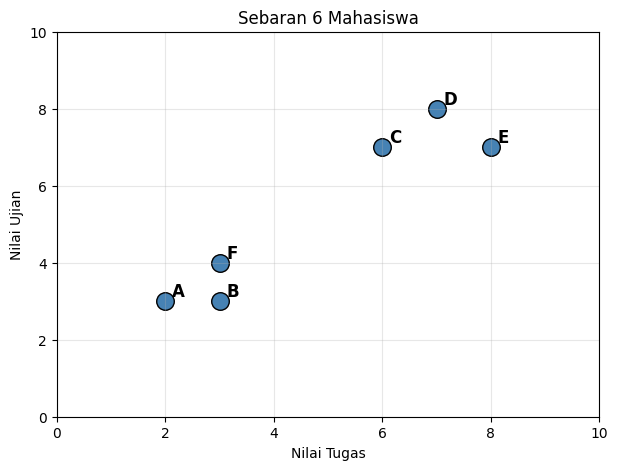

In [2]:
X = data[['Tugas', 'Ujian']].values
label = data['Mhs'].values

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=160, c='steelblue', edgecolors='k')
for i, name in enumerate(label):
    plt.annotate(name, (X[i, 0] + 0.12, X[i, 1] + 0.12), fontsize=12, fontweight='bold')
plt.xlabel('Nilai Tugas')
plt.ylabel('Nilai Ujian')
plt.title('Sebaran 6 Mahasiswa')
plt.grid(alpha=0.3)
plt.xlim(0, 10); plt.ylim(0, 10)
plt.show()

## 2. Matriks Jarak Awal (Euclidean)

Rumus jarak Euclidean dua titik $p$ dan $q$ pada bidang 2D:

$$d(p, q) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2}$$

Karena ada 6 data, matriks jarak berukuran **6 × 6** simetris dengan diagonal nol. Jumlah pasangan unik yang dihitung = $\binom{6}{2} = 15$.

### Penjelasan kode

- `pdist(X)` menghitung jarak Euclidean **pasangan** dan mengembalikan vektor 1D berisi 15 nilai (urutan kolom-mayor).
- `squareform(...)` mengubah vektor tersebut menjadi matriks 6 × 6.
- DataFrame `df_jarak` diberi label baris/kolom A–F dan angka dibulatkan ke 2 desimal supaya mudah dibaca dan di-*trace* tangan.

In [3]:
dist_vec = pdist(X, metric='euclidean')
dist_mat = squareform(dist_vec)

df_jarak = pd.DataFrame(np.round(dist_mat, 2), index=label, columns=label)
df_jarak

,A,B,C,D,E,F
A,0.00,1.0,5.66,7.07,7.21,1.41
B,1.00,0.0,5.00,6.40,6.40,1.00
C,5.66,5.0,0.00,1.41,2.00,4.24
D,7.07,6.4,1.41,0.00,1.41,5.66
E,7.21,6.4,2.00,1.41,0.00,5.83
F,1.41,1.0,4.24,5.66,5.83,0.00


### Penjelasan kode

Cell ini mencetak **15 pasangan jarak** secara terurut dari yang terkecil. Berguna untuk mengecek pasangan mana yang akan digabungkan pertama (jarak terkecil). Pasangan jarak terkecil = kandidat penggabungan awal.

In [4]:
pasangan = []
for i in range(len(label)):
    for j in range(i + 1, len(label)):
        pasangan.append({
            'Pasangan': f'{label[i]}-{label[j]}',
            'Jarak': round(dist_mat[i, j], 4),
        })
df_pasangan = pd.DataFrame(pasangan).sort_values('Jarak').reset_index(drop=True)
df_pasangan

,Pasangan,Jarak
0,A-B,1.0000
1,B-F,1.0000
2,C-D,1.4142
3,A-F,1.4142
4,D-E,1.4142
5,C-E,2.0000
6,C-F,4.2426
7,B-C,5.0000
8,A-C,5.6569
9,D-F,5.6569


## 3. Algoritma Manual: Agglomerative Single Linkage

**Single linkage**: jarak antara dua klaster = jarak **minimum** antar anggota klaster.

$$d_{\text{single}}(C_i, C_j) = \min_{x \in C_i,\; y \in C_j} d(x, y)$$

Algoritma:
1. Inisialisasi: setiap titik adalah klaster sendiri → {A}, {B}, {C}, {D}, {E}, {F}.
2. Cari pasangan klaster dengan jarak terkecil.
3. Gabungkan kedua klaster, catat pada *history*.
4. Update matriks jarak (single linkage = ambil minimum baris/kolom yang digabung).
5. Ulangi sampai tinggal 1 klaster.

### Penjelasan kode

Implementasi **manual** agar tiap iterasi penggabungan kelihatan:

- `klaster` adalah list of list, awalnya tiap data jadi list satu elemen (`[['A'], ['B'], ...]`).
- `M` adalah salinan matriks jarak awal yang akan terus diperkecil setiap iterasi.
- Tiap iterasi: cari indeks `(i, j)` dengan jarak terkecil di luar diagonal lewat `np.unravel_index(np.argmin(...))` setelah mask diagonal diisi tak hingga.
- **Update matriks**: baris/kolom hasil gabungan diisi `min(baris_i, baris_j)` (inilah definisi *single linkage*); baris/kolom lama dihapus.
- *History* menyimpan: pasangan yang digabung, jarak penggabungan, dan komposisi klaster setelah merge — semua dicetak agar mudah disalin ke laporan.

In [5]:
def agglomerative_single(X, label):
    n = len(X)
    klaster = [[label[i]] for i in range(n)]
    M = squareform(pdist(X)).astype(float)
    np.fill_diagonal(M, np.inf)
    history = []

    while len(klaster) > 1:
        # Cari pasangan dengan jarak minimum
        i, j = np.unravel_index(np.argmin(M), M.shape)
        if i > j:
            i, j = j, i
        jarak = M[i, j]

        # Gabungkan klaster i dan j
        ci, cj = klaster[i], klaster[j]
        gabung = ci + cj
        history.append({
            'iter': len(history) + 1,
            'gabung': (ci, cj),
            'jarak': round(jarak, 4),
            'klaster_setelah': None,  # diisi di bawah
        })

        # Update matriks: baris/kolom i diisi min(i, j), lalu baris/kolom j dihapus
        baris_baru = np.minimum(M[i, :], M[j, :])
        baris_baru[i] = np.inf
        M[i, :] = baris_baru
        M[:, i] = baris_baru
        M = np.delete(M, j, axis=0)
        M = np.delete(M, j, axis=1)

        klaster[i] = gabung
        del klaster[j]
        history[-1]['klaster_setelah'] = [list(c) for c in klaster]

    return history

history = agglomerative_single(X, label)

for h in history:
    ci_str = '{' + ','.join(h['gabung'][0]) + '}'
    cj_str = '{' + ','.join(h['gabung'][1]) + '}'
    klaster_str = ', '.join('{' + ','.join(c) + '}' for c in h['klaster_setelah'])
    print(f"Iterasi {h['iter']}: gabung {ci_str} + {cj_str}  jarak={h['jarak']}")
    print(f"   Klaster setelah merge: {klaster_str}\n")

Iterasi 1: gabung {A} + {B}  jarak=1.0
   Klaster setelah merge: {A,B}, {C}, {D}, {E}, {F}

Iterasi 2: gabung {A,B} + {F}  jarak=1.0
   Klaster setelah merge: {A,B,F}, {C}, {D}, {E}

Iterasi 3: gabung {C} + {D}  jarak=1.4142
   Klaster setelah merge: {A,B,F}, {C,D}, {E}

Iterasi 4: gabung {C,D} + {E}  jarak=1.4142
   Klaster setelah merge: {A,B,F}, {C,D,E}

Iterasi 5: gabung {A,B,F} + {C,D,E}  jarak=4.2426
   Klaster setelah merge: {A,B,F,C,D,E}



### Penjelasan kode

Tabel ringkasan urutan penggabungan dari *history* di atas. Kolom `Jarak Merge` adalah ketinggian (height) titik penggabungan di dendrogram nanti. Tabel ini setara dengan *linkage matrix* SciPy versi manusiawi.

In [6]:
ringkasan = []
for h in history:
    ci = '{' + ','.join(h['gabung'][0]) + '}'
    cj = '{' + ','.join(h['gabung'][1]) + '}'
    ringkasan.append({
        'Iterasi': h['iter'],
        'Klaster A': ci,
        'Klaster B': cj,
        'Jarak Merge': h['jarak'],
        'Jumlah Klaster Tersisa': len(h['klaster_setelah']),
    })
pd.DataFrame(ringkasan)

,Iterasi,Klaster A,Klaster B,Jarak Merge,Jumlah Klaster Tersisa
0,1,{A},{B},1.0000,5
1,2,"{A,B}",{F},1.0000,4
2,3,{C},{D},1.4142,3
3,4,"{C,D}",{E},1.4142,2
4,5,"{A,B,F}","{C,D,E}",4.2426,1


## 4. Linkage Matrix SciPy (Verifikasi)

SciPy `linkage(X, method='single')` mengembalikan **linkage matrix** Z dengan kolom:

| Kol | Arti |
|-----|------|
| 0   | indeks klaster A yang digabung |
| 1   | indeks klaster B yang digabung |
| 2   | jarak saat penggabungan |
| 3   | jumlah titik dalam klaster gabungan |

Indeks 0..n-1 = titik asli, indeks n..2n-2 = klaster hasil merge sebelumnya. Hasil kolom 2 (jarak) harus sama dengan yang kita hitung manual.

### Penjelasan kode

- `linkage(X, method='single')` menjalankan agglomerative single-linkage versi SciPy.
- `Z` ditampilkan lewat DataFrame agar mudah dibandingkan dengan ringkasan manual di Section 3.
- Kolom **Jarak** pada Z harus identik (kurang lebih) dengan kolom `Jarak Merge` di tabel manual. Bila identik, implementasi manual sudah benar.

In [7]:
Z = linkage(X, method='single', metric='euclidean')
df_Z = pd.DataFrame(Z, columns=['ClusterA', 'ClusterB', 'Jarak', 'JumlahAnggota'])
df_Z

,ClusterA,ClusterB,Jarak,JumlahAnggota
0,0.0,1.0,1.000000,2.0
1,5.0,6.0,1.000000,3.0
2,2.0,3.0,1.414214,2.0
3,4.0,8.0,1.414214,3.0
4,7.0,9.0,4.242641,6.0


## 5. Dendrogram

Dendrogram adalah diagram pohon yang memperlihatkan **urutan penggabungan** dan **ketinggian** (= jarak saat merge).

Cara membaca:
- Daun = data asli (A..F).
- Garis vertikal dua titik digabung pada **ketinggian = jarak merge** mereka.
- Memotong dendrogram pada ketinggian tertentu menghasilkan partisi klaster pada ketinggian itu.

### Penjelasan kode

- `dendrogram(Z, labels=label)` menggambar dendrogram dari linkage matrix `Z`.
- Garis horizontal merah putus-putus pada `y=2.5` adalah **garis potong**: di bawahnya terbentuk 2 klaster (kelompok nilai rendah dan tinggi).
- Memvariasikan `y` garis potong akan mengubah jumlah klaster terbentuk: makin tinggi makin sedikit klaster.

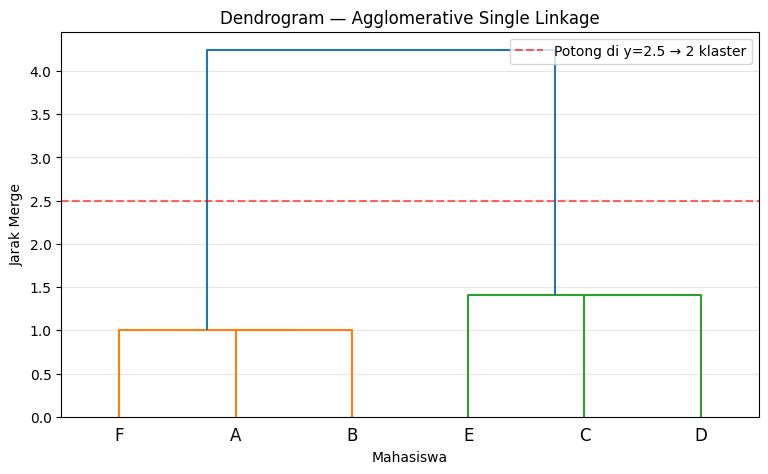

In [8]:
plt.figure(figsize=(9, 5))
dendrogram(
    Z,
    labels=label,
    leaf_font_size=12,
    color_threshold=2.5,
)
plt.axhline(y=2.5, color='red', linestyle='--', alpha=0.6, label='Potong di y=2.5 → 2 klaster')
plt.title('Dendrogram — Agglomerative Single Linkage')
plt.xlabel('Mahasiswa')
plt.ylabel('Jarak Merge')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 6. Perbandingan Metode Linkage

Selain *single linkage*, ada beberapa pilihan lain dengan cara hitung jarak antar klaster berbeda:

| Method | Definisi | Karakter |
|--------|----------|----------|
| `single` | minimum antar anggota | rentan *chaining*, klaster bisa memanjang |
| `complete` | maksimum antar anggota | klaster lebih kompak |
| `average` | rata-rata semua pasangan | kompromi single & complete |
| `ward` | minimalkan kenaikan SSE | biasanya menghasilkan klaster seimbang |

### Penjelasan kode

- Loop 4 metode linkage. Untuk tiap metode hitung `linkage(X, method=...)` dan gambar dendrogram pada subplot.
- Subplot 2 × 2 memudahkan melihat bagaimana struktur pohon berubah tergantung definisi jarak antar klaster.
- Skala sumbu Y berbeda antar metode adalah hal wajar karena definisi jaraknya berbeda.

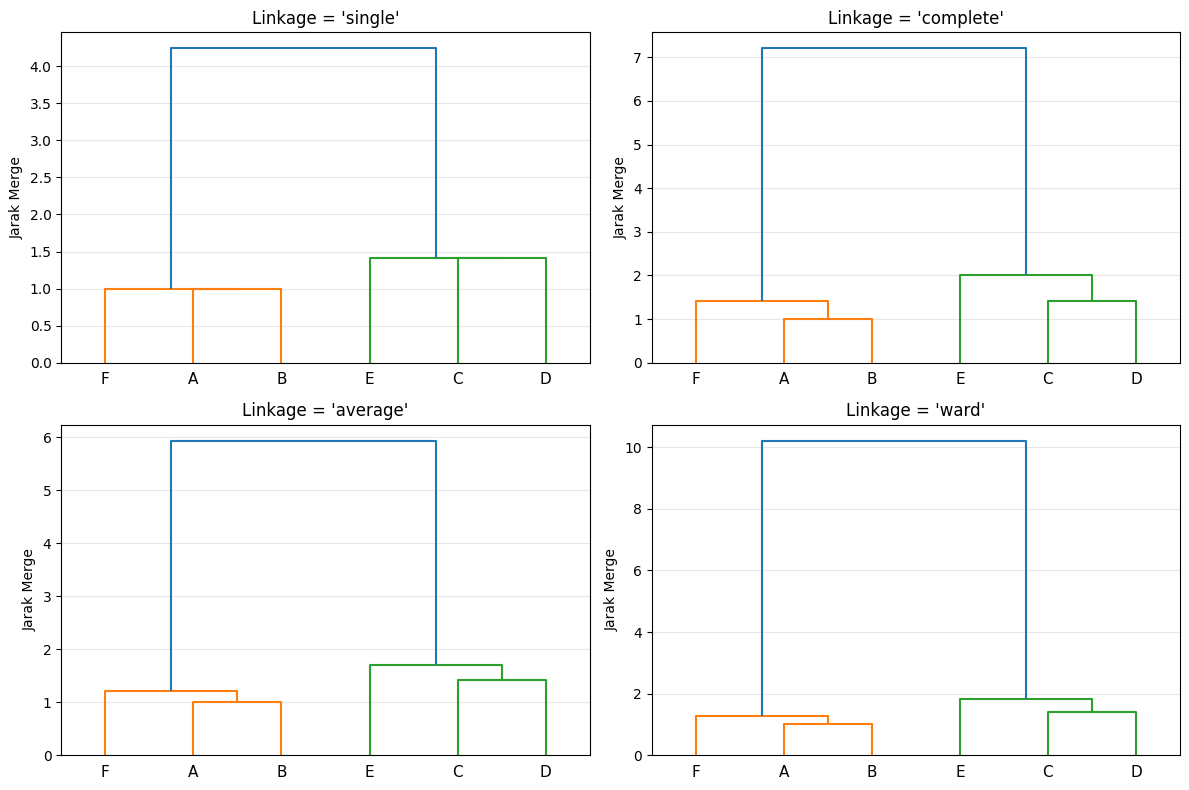

In [9]:
metode = ['single', 'complete', 'average', 'ward']
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
for ax, m in zip(axs.flatten(), metode):
    Zm = linkage(X, method=m, metric='euclidean')
    dendrogram(Zm, labels=label, ax=ax, leaf_font_size=11)
    ax.set_title(f"Linkage = '{m}'")
    ax.set_ylabel('Jarak Merge')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Ambil Label Klaster (Cut Tree)

Setelah dendrogram terbentuk, kita dapat memilih **jumlah klaster** dengan dua cara:
1. Potong dendrogram pada ketinggian tertentu (`fcluster(..., criterion='distance')`).
2. Pilih `n_clusters` langsung (`fcluster(..., criterion='maxclust')` atau `AgglomerativeClustering(n_clusters=...)`).

### Penjelasan kode

- `fcluster(Z, t=2, criterion='maxclust')` memotong dendrogram sehingga menghasilkan paling banyak **2 klaster**.
- `AgglomerativeClustering` dari sklearn dijalankan dengan parameter setara (`n_clusters=2`, `linkage='single'`) sebagai validasi silang. Label keduanya seharusnya menghasilkan pengelompokan yang sama (penamaan angka boleh berbeda, yang penting *isi* klaster sama).
- Scatter plot terakhir mewarnai titik per klaster.

In [10]:
# Potong dendrogram menjadi 2 klaster
label_scipy = fcluster(Z, t=2, criterion='maxclust')

# Bandingkan dengan sklearn AgglomerativeClustering
ac = AgglomerativeClustering(n_clusters=2, linkage='single', metric='euclidean')
label_sklearn = ac.fit_predict(X)

df_label = data.copy()
df_label['Klaster (SciPy)']   = label_scipy
df_label['Klaster (sklearn)'] = label_sklearn
df_label

,Mhs,Tugas,Ujian,Klaster (SciPy),Klaster (sklearn)
0,A,2,3,1,1
1,B,3,3,1,1
2,C,6,7,2,0
3,D,7,8,2,0
4,E,8,7,2,0
5,F,3,4,1,1


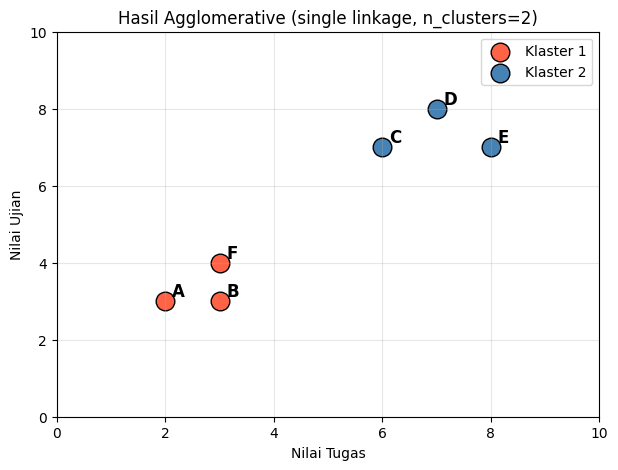

In [11]:
plt.figure(figsize=(7, 5))
warna = {1: 'tomato', 2: 'steelblue'}
for k in np.unique(label_scipy):
    pts = X[label_scipy == k]
    plt.scatter(pts[:, 0], pts[:, 1], c=warna[k], s=180, edgecolors='k', label=f'Klaster {k}')
for i, name in enumerate(label):
    plt.annotate(name, (X[i, 0] + 0.12, X[i, 1] + 0.12), fontsize=12, fontweight='bold')
plt.xlabel('Nilai Tugas'); plt.ylabel('Nilai Ujian')
plt.title('Hasil Agglomerative (single linkage, n_clusters=2)')
plt.legend(); plt.grid(alpha=0.3)
plt.xlim(0, 10); plt.ylim(0, 10)
plt.show()

## 8. Kesimpulan

1. Agglomerative clustering bekerja *bottom-up*: mulai dari $n$ klaster (setiap titik sendiri) sampai 1 klaster besar.
2. Pada studi kasus 6 mahasiswa, urutan penggabungan dengan **single linkage** adalah:
   - Iterasi 1: pasangan terdekat digabung (lihat tabel ringkasan).
   - Iterasi terakhir: dua kelompok besar bergabung menjadi satu.
3. **Dendrogram** memperlihatkan seluruh hirarki, dan memotongnya pada ketinggian tertentu memberi partisi klaster.
4. Pemilihan **linkage** mempengaruhi bentuk klaster:
   - *single*: mudah membentuk klaster memanjang (efek *chaining*).
   - *complete*/*ward*: cenderung kompak dan seimbang.
5. Hasil manual cocok dengan SciPy `linkage` dan sklearn `AgglomerativeClustering`, memvalidasi langkah perhitungan.
6. Kelebihan dibanding K-Means: **tidak perlu menentukan K di awal** dan menghasilkan struktur hirarkis. Kekurangan: kompleksitas $O(n^3)$ pada implementasi naif sehingga kurang cocok untuk data sangat besar.

## 9. Referensi / Daftar Pustaka

Rumus dan metode yang dipakai pada notebook ini bersumber dari literatur berikut. Tabel pertama memetakan tiap rumus/konsep ke sumbernya, lalu daftar pustaka lengkap diberikan di bawahnya.

### Pemetaan rumus → sumber

| Konsep / rumus di notebook | Sumber |
|---|---|
| Jarak **Euclidean** (Section 2) | Han, Kamber & Pei (2012, §2.4); Tan, Steinbach & Kumar (2019) |
| Konsep **agglomerative hierarchical clustering** (AGNES) & **dendrogram** | Han, Kamber & Pei (2012, Bab 10); Jain, Murty & Flynn (1999); Everitt dkk. (2011) |
| Aturan **update matriks jarak** (rumus rekursif umum semua linkage) | Lance & Williams (1967) |
| **Single linkage** — jarak minimum (Section 3) | Sibson (1973); Gower & Ross (1969) |
| **Complete linkage** — jarak maksimum (Section 6) | Defays (1977) |
| **Average linkage / UPGMA** — rata-rata pasangan (Section 6) | Sokal & Michener (1958) |
| **Ward linkage** — minimalkan kenaikan SSE (Section 6) | Ward (1963); Murtagh & Legendre (2014) |
| Algoritma implementasi *linkage matrix* (dasar `scipy.linkage`) | Müllner (2011) |
| Library `scipy.cluster.hierarchy` (`linkage`, `dendrogram`, `fcluster`) | Virtanen dkk. (2020) |
| `sklearn.cluster.AgglomerativeClustering` | Pedregosa dkk. (2011) |

> Catatan: *rumus rekursif Lance–Williams* (1967) adalah formula umum yang menyatukan semua metode linkage (single, complete, average, Ward) ke dalam satu persamaan update jarak — inilah yang diimplementasikan SciPy/sklearn secara internal.

### Daftar pustaka

**Jurnal & artikel**

1. Defays, D. (1977). An efficient algorithm for a complete link method. *The Computer Journal, 20*(4), 364–366. https://doi.org/10.1093/comjnl/20.4.364
2. Gower, J. C., & Ross, G. J. S. (1969). Minimum spanning trees and single linkage cluster analysis. *Journal of the Royal Statistical Society: Series C (Applied Statistics), 18*(1), 54–64. https://doi.org/10.2307/2346439
3. Jain, A. K. (2010). Data clustering: 50 years beyond K-means. *Pattern Recognition Letters, 31*(8), 651–666. https://doi.org/10.1016/j.patrec.2009.09.011
4. Jain, A. K., Murty, M. N., & Flynn, P. J. (1999). Data clustering: A review. *ACM Computing Surveys, 31*(3), 264–323. https://doi.org/10.1145/331499.331504
5. Lance, G. N., & Williams, W. T. (1967). A general theory of classificatory sorting strategies: 1. Hierarchical systems. *The Computer Journal, 9*(4), 373–380. https://doi.org/10.1093/comjnl/9.4.373
6. Müllner, D. (2011). Modern hierarchical, agglomerative clustering algorithms. *arXiv preprint* arXiv:1109.2378. https://arxiv.org/abs/1109.2378
7. Murtagh, F., & Legendre, P. (2014). Ward's hierarchical agglomerative clustering method: Which algorithms implement Ward's criterion? *Journal of Classification, 31*(3), 274–295. https://doi.org/10.1007/s00357-014-9161-z
8. Pedregosa, F., dkk. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html
9. Sibson, R. (1973). SLINK: An optimally efficient algorithm for the single-link cluster method. *The Computer Journal, 16*(1), 30–34. https://doi.org/10.1093/comjnl/16.1.30
10. Sokal, R. R., & Michener, C. D. (1958). A statistical method for evaluating systematic relationships. *University of Kansas Science Bulletin, 38*, 1409–1438.
11. Virtanen, P., dkk. (2020). SciPy 1.0: Fundamental algorithms for scientific computing in Python. *Nature Methods, 17*(3), 261–272. https://doi.org/10.1038/s41592-019-0686-2
12. Ward, J. H. (1963). Hierarchical grouping to optimize an objective function. *Journal of the American Statistical Association, 58*(301), 236–244. https://doi.org/10.1080/01621459.1963.10500845

**Buku teks**

13. Everitt, B. S., Landau, S., Leese, M., & Stahl, D. (2011). *Cluster Analysis* (5th ed.). Wiley. https://doi.org/10.1002/9780470977811
14. Han, J., Kamber, M., & Pei, J. (2012). *Data Mining: Concepts and Techniques* (3rd ed.). Morgan Kaufmann.
15. Tan, P.-N., Steinbach, M., Karpatne, A., & Kumar, V. (2019). *Introduction to Data Mining* (2nd ed.). Pearson.